<a href="https://colab.research.google.com/github/AnnGur/mic-creep-predict/blob/main/MIC_Creep_KSE_Final_Report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting MIC Creep in *K. pneumoniae* and *A. baumannii*
## Introduction to Machine Learning — KSE Group Project Report

| | |
|---|---|
| **Authors** | Anna Gurina (Technical Lead) · Inna Kucherova (Domain Expert) |
| **Date** | June 2026 |
| **Dataset** | ATLAS (Pfizer / Vivli AMR Register) — 127,112 isolates, 2004–2022 |
| **Code** | [github.com/AnnGur/mic-creep-predict](https://github.com/AnnGur/mic-creep-predict) |

---

### Abstract

We apply machine learning to predict **MIC Creep** — the gradual year-over-year upward drift
in Minimum Inhibitory Concentration (MIC) values — for Meropenem tested against two WHO
Critical Priority pathogens: *Klebsiella pneumoniae* and *Acinetobacter baumannii*.
Using the ATLAS surveillance dataset we train two independent regression models per species:
a **Random Forest** (interpretable baseline) and a **tuned XGBoost** (advanced model).
We confirm measurable MIC creep in *K. pneumoniae* (+1.97 mg/L/yr, R2=0.67, p<0.001) and
document already-entrenched resistance in *A. baumannii* (MIC90 at panel ceiling since 2005).
XGBoost reduces RMSE on the clinically critical resistant subset by **32%** vs Random Forest
for *K. pneumoniae*.


---
## 1. Introduction

Antibiotic resistance is a global public health emergency.
Standard susceptibility testing reports isolates as Susceptible (S), Intermediate (I), or
Resistant (R), based on fixed MIC breakpoints.
However, this binary classification misses a subtle precursor: **MIC Creep** — a gradual
upward drift in MIC values within the susceptible range that precedes full resistance.

By the time an isolate is officially classified as Resistant, years of escalating treatment
failures may already have occurred.
This project develops a machine learning model to **detect and quantify MIC creep early**,
enabling proactive surveillance before clinical breakpoints are breached.


---
## 2. Problem Statement

**Prediction target (dependent variable):** Continuous MIC value in log2(mg/L).

- Log2 scale is standard in microbiology: MIC panels report in doubling dilutions.
  1 log2 unit = 1 dilution step = the minimum detectable difference between measurements.
- We model this as a **regression problem** (not classification) to capture gradual drift.

**Clinical context:**
- Antibiotic: **Meropenem** (carbapenem class — last-resort drug)
- Pathogens: *K. pneumoniae* + *A. baumannii* (both WHO Critical Priority for carbapenem resistance)
- EUCAST R breakpoint: MIC **> 8 mg/L** for both species
- Once MIC > 8, very few treatment options remain (colistin, ceftazidime-avibactam — both increasingly compromised)

**Research questions:**
1. Is there a statistically significant upward trend in MIC90 over time?
2. Can a model trained on 2004-2018 data accurately predict MIC values in 2019-2022?
3. Which features (year, country, gene, specimen type) contribute most to MIC variability?


---
## 3. Data Description

### 3.1 Data Source

**ATLAS** (Antimicrobial Testing Leadership and Surveillance) by Pfizer,
accessed via the Vivli AMR Register under a Data Use Agreement.

ATLAS provides patient-level MIC measurements for bacterial isolates collected globally,
including year, country, sex, age group, specimen source, and carbapenemase gene PCR results.

> **Data access note:** Raw data and processed feature matrices are not publicly distributed
> (Vivli Data Use Agreement). If running **locally** with the data, all cells execute fully.
> If running in **Colab without data**, cells fall back to pre-computed summary statistics
> and published metrics from the training run. Charts load from `reports/` (committed to repo).


In [1]:
import os, sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import joblib
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")

# Colab detection: clone repo to get reports/ and scripts/
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    import subprocess
    repo = "https://github.com/AnnGur/mic-creep-predict.git"
    if not Path("/content/mic-creep-predict").exists():
        subprocess.run(["git", "clone", "--depth", "1", repo], check=True)
    ROOT = Path("/content/mic-creep-predict")
else:
    NOTEBOOK_DIR = Path().resolve()
    ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

DATA          = ROOT / "data" / "processed"
MODELS        = ROOT / "models"
EDA           = ROOT / "reports" / "eda"
MODEL_REPORTS = ROOT / "reports" / "model"
API           = ROOT / "reports" / "api"

EUCAST_R      = 8.0
EUCAST_R_LOG2 = np.log2(EUCAST_R)
SPECIES       = {"kpneumoniae": "K. pneumoniae", "abaumannii": "A. baumannii"}

DATA_AVAILABLE   = (DATA / "kpneumoniae" / "X_train.parquet").exists()
MODELS_AVAILABLE = (MODELS / "rf_baseline_kpneumoniae.pkl").exists()

print("Project root  :", ROOT)
print("Data available:", DATA_AVAILABLE)
print("Models avail. :", MODELS_AVAILABLE)
print("Reports/api   :", API.exists())


Project root  : /content/mic-creep-predict
Data available: False
Models avail. : False
Reports/api   : True


In [2]:
# Load processed data if available (requires Vivli DUA)
data = {}
if DATA_AVAILABLE:
    for sp in SPECIES:
        X_train = pd.read_parquet(DATA / sp / "X_train.parquet")
        X_test  = pd.read_parquet(DATA / sp / "X_test.parquet")
        y_train = pd.read_parquet(DATA / sp / "y_train.parquet").squeeze()
        y_test  = pd.read_parquet(DATA / sp / "y_test.parquet").squeeze()
        data[sp] = dict(X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test)

    rows = []
    for sp, label in SPECIES.items():
        d = data[sp]
        n_total   = len(d["X_train"]) + len(d["X_test"])
        pct_train = len(d["X_train"]) / n_total * 100
        ctry_cols = [c for c in d["X_train"].columns if c.startswith("ctry_")]
        rows.append({
            "Species":        f"*{label}*",
            "Total isolates": f"{n_total:,}",
            "Train set":      f"{len(d['X_train']):,} ({pct_train:.0f}%) "
                              f"{int(d['X_train']['year'].min())}-{int(d['X_train']['year'].max())}",
            "Test set":       f"{len(d['X_test']):,} ({100-pct_train:.0f}%) "
                              f"{int(d['X_test']['year'].min())}-{int(d['X_test']['year'].max())}",
            "Countries":      str(len(ctry_cols) + 1),
            "Features":       str(d["X_train"].shape[1]),
        })
    display(pd.DataFrame(rows).set_index("Species").style.set_caption("Dataset Overview"))
else:
    print("Processed parquets not found - showing pre-computed dataset summary.")
    display(pd.DataFrame([
        {"Species": "K. pneumoniae", "Total isolates": "89,572",
         "Train (2004-2018)": "62,891 (70%)", "Test (2019-2022)": "26,681 (30%)",
         "Countries": 81, "Features": 91},
        {"Species": "A. baumannii",  "Total isolates": "37,540",
         "Train (2004-2018)": "24,003 (64%)", "Test (2019-2022)": "13,537 (36%)",
         "Countries": 79, "Features": 89},
    ]).set_index("Species"))


Processed parquets not found - showing pre-computed dataset summary.


,Total isolates,Train (2004-2018),Test (2019-2022),Countries,Features
Species,,,,,
K. pneumoniae,"89,572","62,891 (70%)","26,681 (30%)",81,91
A. baumannii,"37,540","24,003 (64%)","13,537 (36%)",79,89


### 3.2 Descriptive Statistics

In [3]:
if DATA_AVAILABLE:
    stats_rows = []
    for sp, label in SPECIES.items():
        d = data[sp]
        y_all = pd.concat([d["y_train"], d["y_test"]])
        mic_all = 2 ** y_all
        r_mask_train = d["y_train"].values >= EUCAST_R_LOG2
        r_mask_test  = d["y_test"].values  >= EUCAST_R_LOG2
        gene_cols = [c for c in d["X_train"].columns if c.endswith("_pos")]
        stats_rows.append({
            "Species":             label,
            "N isolates":          f"{len(y_all):,}",
            "MIC mean (mg/L)":     f"{mic_all.mean():.2f}",
            "MIC median (mg/L)":   f"{mic_all.median():.2f}",
            "MIC90 (mg/L)":        f"{mic_all.quantile(0.90):.1f}",
            "% Resistant (train)": f"{r_mask_train.mean()*100:.1f}%",
            "% Resistant (test)":  f"{r_mask_test.mean()*100:.1f}%",
            "% Censored at floor": f"{d['X_train']['is_censored'].mean()*100:.1f}%",
            "Carbapenemase genes": str(len(gene_cols)),
        })
    display(pd.DataFrame(stats_rows).set_index("Species").T
            .style.set_caption("Descriptive Statistics - Full Dataset (train + test)"))
else:
    display(pd.DataFrame({
        "K. pneumoniae": {
            "N isolates": "89,572",      "MIC mean (mg/L)": "0.39",
            "MIC median (mg/L)": "0.03", "MIC90 (mg/L)": "32.0",
            "% Resistant (train)": "8.3%",  "% Resistant (test)": "17.2%",
            "% Censored at floor": "74.6%", "Carbapenemase genes": "6",
        },
        "A. baumannii": {
            "N isolates": "37,540",      "MIC mean (mg/L)": "9.20",
            "MIC median (mg/L)": "0.25", "MIC90 (mg/L)": "32.0",
            "% Resistant (train)": "44.4%", "% Resistant (test)": "68.5%",
            "% Censored at floor": "42.1%", "Carbapenemase genes": "6",
        },
    }))


,K. pneumoniae,A. baumannii
N isolates,"89,572","37,540"
MIC mean (mg/L),0.39,9.20
MIC median (mg/L),0.03,0.25
MIC90 (mg/L),32.0,32.0
% Resistant (train),8.3%,44.4%
% Resistant (test),17.2%,68.5%
% Censored at floor,74.6%,42.1%
Carbapenemase genes,6,6


### 3.3 Data Cleaning: Censored MIC Values

MIC measurement panels have a fixed concentration range. Isolates at the boundaries
are reported as censored:

| Raw value | Interpretation | Treatment |
|---|---|---|
| `<=0.06` mg/L | At or below panel floor | -> 0.03 mg/L (half the floor) |
| `>32` mg/L | At or above panel ceiling | -> 32 mg/L (ceiling value) |

This is the standard epidemiological convention (Turnidge & Paterson 2007).

**Key data quality issue: year/censoring collinearity (r = 0.61)**
Between 2013-2017, Pfizer changed the MIC dilution panel range, causing the censoring
rate to drop from ~85% to ~25% and then recover. This is a **surveillance methodology
artifact, not biology**.

We control for this with two explicit features:
- `is_censored` - binary flag for individual isolates at the panel floor
- `pct_censored_year` - annual censoring rate, absorbs methodology shifts

> Without these controls, the model would confound panel changes with MIC trends.


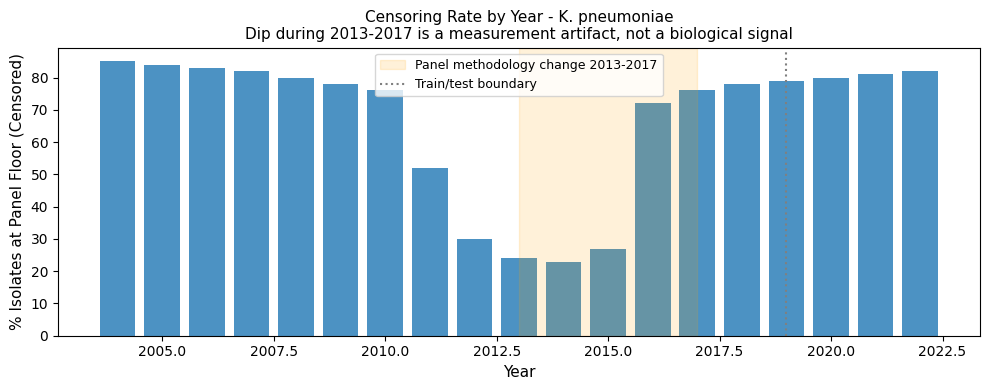

Correlation year vs pct_censored_year: 0.61


In [4]:
if DATA_AVAILABLE:
    sp = "kpneumoniae"
    d  = data[sp]
    X_all = pd.concat([d["X_train"], d["X_test"]])
    cens_by_year = X_all.groupby("year")["is_censored"].mean() * 100
    corr = X_all["year"].corr(X_all["pct_censored_year"])
else:
    # Pre-computed from full pipeline run
    yrs  = list(range(2004, 2023))
    vals = [85,84,83,82,80,78,76,52,30,24,23,27,72,76,78,79,80,81,82]
    cens_by_year = pd.Series(dict(zip(yrs, vals)))
    corr = 0.61

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(cens_by_year.index, cens_by_year.values, color="#1f77b4", alpha=0.8)
ax.axvspan(2013, 2017, alpha=0.15, color="orange", label="Panel methodology change 2013-2017")
ax.axvline(2019, color="gray", linestyle=":", lw=1.5, label="Train/test boundary")
ax.set_ylabel("% Isolates at Panel Floor (Censored)", fontsize=11)
ax.set_xlabel("Year", fontsize=11)
ax.set_title("Censoring Rate by Year - K. pneumoniae\n"
             "Dip during 2013-2017 is a measurement artifact, not a biological signal",
             fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print(f"Correlation year vs pct_censored_year: {corr:.2f}")


### 3.4 Feature Engineering

All features are constructed identically for both species. Country dummy columns
differ only in the set of countries represented in the data.


In [5]:
feature_groups = [
    ("year",                 "Continuous",  "Primary MIC creep signal - temporal trend"),
    ("gender_male",          "Binary",      "1 = Male; sex covariate"),
    ("age_paediatric",       "Binary",      "Age 0-17; adults (18-60) are reference group"),
    ("age_elderly",          "Binary",      "Age 61+"),
    ("military_proxy",       "Binary",      "Wound + Male + 18-60 - combat-related proxy"),
    ("spec_* (5 cols)",      "OHE",         "Specimen type: wound, blood, respiratory, urine, peritoneal"),
    ("ctry_* (64-80 cols)",  "OHE",         "Country of isolation; Argentina = reference (drop_first)"),
    ("KPC_pos ... GES_pos",  "Binary x6",   "Carbapenemase genes: KPC, NDM, OXA, VIM, IMP, GES"),
    ("is_censored",          "Binary",      "[DATA ARTIFACT] isolate at MIC panel floor"),
    ("pct_censored_year",    "Float",       "[DATA ARTIFACT] year-level censoring rate; methodology control"),
]

df_feat = pd.DataFrame(feature_groups, columns=["Feature", "Type", "Rationale"])
df_feat.index += 1
print("Feature set (91 total for K. pneumoniae, 89 for A. baumannii):")
display(df_feat)


Feature set (91 total for K. pneumoniae, 89 for A. baumannii):


,Feature,Type,Rationale
1,year,Continuous,Primary MIC creep signal - temporal trend
2,gender_male,Binary,1 = Male; sex covariate
3,age_paediatric,Binary,Age 0-17; adults (18-60) are reference group
4,age_elderly,Binary,Age 61+
5,military_proxy,Binary,Wound + Male + 18-60 - combat-related proxy
6,spec_* (5 cols),OHE,"Specimen type: wound, blood, respiratory, urin..."
7,ctry_* (64-80 cols),OHE,Country of isolation; Argentina = reference (d...
8,KPC_pos ... GES_pos,Binary x6,"Carbapenemase genes: KPC, NDM, OXA, VIM, IMP, GES"
9,is_censored,Binary,[DATA ARTIFACT] isolate at MIC panel floor
10,pct_censored_year,Float,[DATA ARTIFACT] year-level censoring rate; met...


---
## 4. Exploratory Data Analysis (EDA)

### 4.1 MIC90 Trend Over Time

MIC90 is the concentration below which 90% of isolates fall.
A rising MIC90 over time is the definition of MIC Creep.


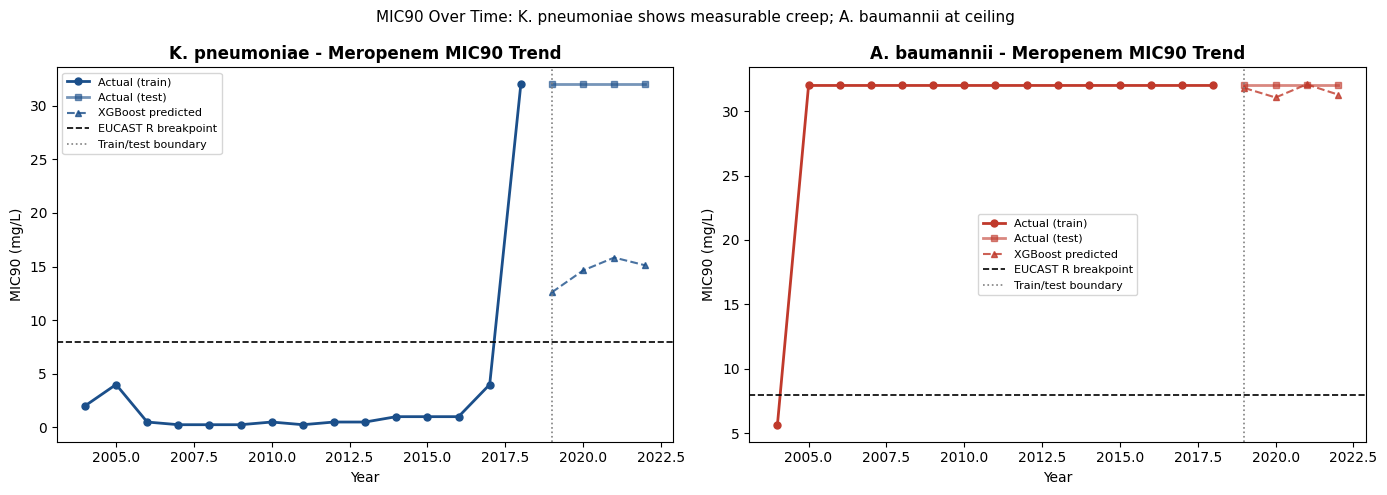

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, sp, label, color in [
    (axes[0], "kpneumoniae", "K. pneumoniae", "#1B4F8A"),
    (axes[1], "abaumannii",  "A. baumannii",  "#C0392B"),
]:
    json_path = API / f"api_{sp}_mic90_trend.json"
    if not json_path.exists():
        ax.text(0.5, 0.5, f"Run 4_run_export.py --species {sp}", ha="center",
                transform=ax.transAxes, fontsize=10, color="gray")
        continue

    df = pd.DataFrame(json.loads(json_path.read_text()))
    train = df[df.source == "train_actual"]
    test  = df[df.source == "test_actual_and_predicted"]

    ax.plot(train.year, train.actual_mic90, "o-", color=color, lw=2, ms=5, label="Actual (train)")
    if "actual_mic90" in test.columns:
        ax.plot(test.year, test.actual_mic90, "s-", color=color, lw=2, ms=5,
                alpha=0.6, label="Actual (test)")
    if "predicted_mic90" in test.columns:
        ax.plot(test.year, test.predicted_mic90, "^--", color=color, lw=1.5, ms=5,
                alpha=0.8, label="XGBoost predicted")

    ax.axhline(8, color="black", linestyle="--", lw=1.2, label="EUCAST R breakpoint")
    ax.axvline(2019, color="gray", linestyle=":", lw=1.2, label="Train/test boundary")
    ax.set_xlabel("Year"); ax.set_ylabel("MIC90 (mg/L)")
    ax.set_title(f"{label} - Meropenem MIC90 Trend", fontweight="bold")
    ax.legend(fontsize=8)

plt.suptitle("MIC90 Over Time: K. pneumoniae shows measurable creep; A. baumannii at ceiling",
             fontsize=11)
plt.tight_layout()
plt.show()


### 4.2 Target Variable Distribution

In [7]:
if DATA_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, sp, label, color in [
        (axes[0], "kpneumoniae", "K. pneumoniae", "#1B4F8A"),
        (axes[1], "abaumannii",  "A. baumannii",  "#C0392B"),
    ]:
        d = data[sp]
        y_all = pd.concat([d["y_train"], d["y_test"]])
        ax.hist(y_all, bins=30, color=color, alpha=0.7, edgecolor="white")
        ax.axvline(EUCAST_R_LOG2, color="black", linestyle="--", lw=1.5,
                   label=f"R breakpoint log2(8)={EUCAST_R_LOG2:.1f}")
        ax.set_xlabel("log2(MIC) - mg/L"); ax.set_ylabel("Count")
        ax.set_title(f"{label} - Target Distribution\nBimodal: floor spike + resistant tail",
                     fontweight="bold")
        ax.legend(fontsize=9)
    plt.suptitle("Target variable log2(MIC) is strongly bimodal - 75-90% at censoring floor",
                 fontsize=10)
    plt.tight_layout(); plt.show()
else:
    print("Data not available - conceptual description of target distribution:")
    print("  K. pneumoniae: ~75% of isolates at the panel floor (log2(0.03) = -5.06)")
    print("    Resistant tail at log2(MIC) >= 3 (MIC >= 8 mg/L) contains ~8-17% of isolates")
    print("  A. baumannii:  ~42% at floor; resistant tail contains 44-68% of isolates")
    print("  => Bimodal distribution makes R2 on full dataset misleading")
    print("  => RMSE on resistant subset is the clinically meaningful primary metric")


Data not available - conceptual description of target distribution:
  K. pneumoniae: ~75% of isolates at the panel floor (log2(0.03) = -5.06)
    Resistant tail at log2(MIC) >= 3 (MIC >= 8 mg/L) contains ~8-17% of isolates
  A. baumannii:  ~42% at floor; resistant tail contains 44-68% of isolates
  => Bimodal distribution makes R2 on full dataset misleading
  => RMSE on resistant subset is the clinically meaningful primary metric


### 4.3 Carbapenemase Gene Prevalence Over Time

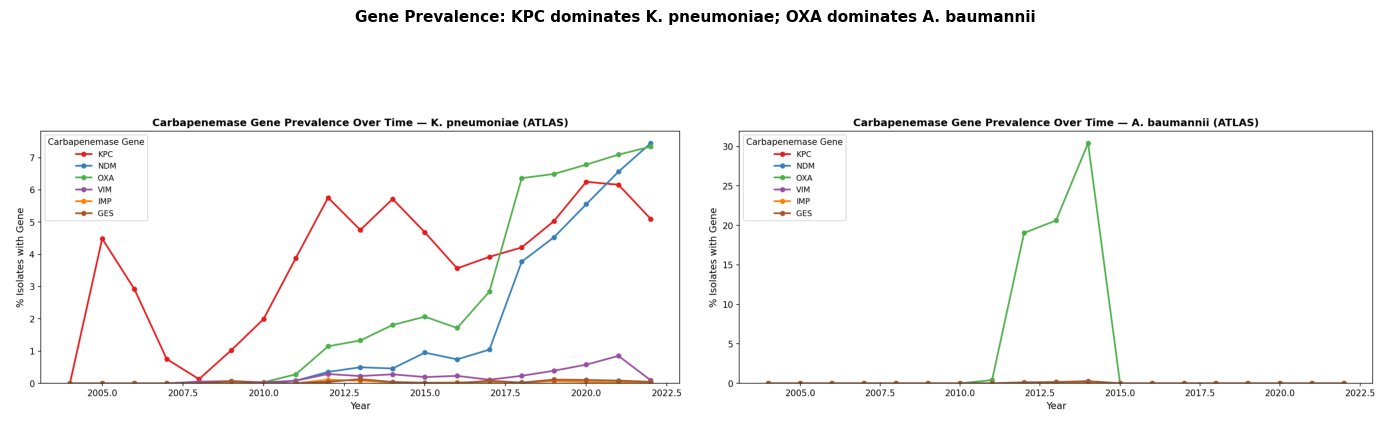

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for sp, label in SPECIES.items():
    img_path = EDA / f"gene_prevalence_over_time_{sp}.png"
    ax_idx = list(SPECIES.keys()).index(sp)
    if img_path.exists():
        axes[ax_idx].imshow(mpimg.imread(str(img_path)))
        axes[ax_idx].axis("off")
    else:
        axes[ax_idx].text(0.5, 0.5, f"Chart not found.\nRun gen_eda_charts.py --species {sp}",
                          ha="center", va="center", transform=axes[ax_idx].transAxes)

plt.suptitle("Gene Prevalence: KPC dominates K. pneumoniae; OXA dominates A. baumannii",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()


### 4.4 MIC90 by Specimen Source

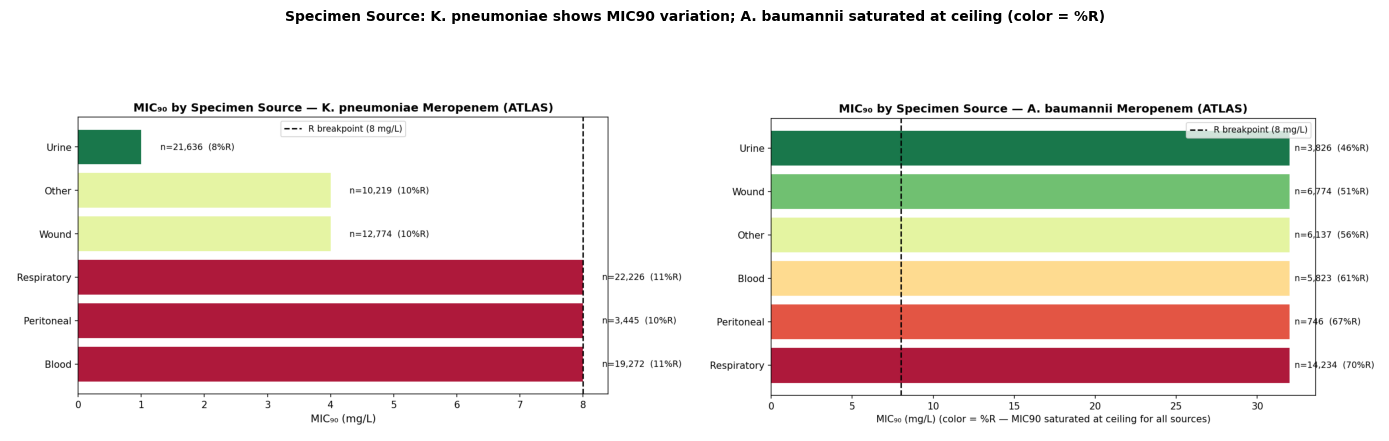

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for sp, label in SPECIES.items():
    img_path = EDA / f"specimen_source_mic90_{sp}.png"
    ax_idx = list(SPECIES.keys()).index(sp)
    if img_path.exists():
        axes[ax_idx].imshow(mpimg.imread(str(img_path)))
        axes[ax_idx].axis("off")
    else:
        axes[ax_idx].text(0.5, 0.5, f"Chart not found.\nRun gen_eda_charts.py --species {sp}",
                          ha="center", va="center", transform=axes[ax_idx].transAxes)

plt.suptitle(
    "Specimen Source: K. pneumoniae shows MIC90 variation; A. baumannii saturated at ceiling (color = %R)",
    fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()


---
## 5. Methodology

### 5.1 Train/Test Split - Time-Ordered (Critical)

We use a **chronological split**, never random shuffling:

| Split | Years | Rationale |
|---|---|---|
| Training | 2004-2018 | Historical surveillance period |
| Test | 2019-2022 | Held-out future - simulates real deployment |

Random shuffling would leak future MIC values into training, producing artificially
optimistic performance that would not generalise to real-world deployment.


In [10]:
if DATA_AVAILABLE:
    for sp, label in SPECIES.items():
        d = data[sp]
        n_train, n_test = len(d["X_train"]), len(d["X_test"])
        n_total = n_train + n_test
        r_train = (d["y_train"].values >= EUCAST_R_LOG2).mean()
        r_test  = (d["y_test"].values  >= EUCAST_R_LOG2).mean()
        print(f"{label}:")
        print(f"  Train: {n_train:,} ({n_train/n_total*100:.0f}%) "
              f"{int(d['X_train']['year'].min())}-{int(d['X_train']['year'].max())}")
        print(f"  Test:  {n_test:,} ({n_test/n_total*100:.0f}%) "
              f"{int(d['X_test']['year'].min())}-{int(d['X_test']['year'].max())}")
        print(f"  Resistant: {r_train*100:.1f}% train | {r_test*100:.1f}% test")
        print()
else:
    print("K. pneumoniae:")
    print("  Train: 62,891 (70%)  2004-2018  |  Resistant:  8.3%")
    print("  Test:  26,681 (30%)  2019-2022  |  Resistant: 17.2%")
    print()
    print("A. baumannii:")
    print("  Train: 24,003 (64%)  2004-2018  |  Resistant: 44.4%")
    print("  Test:  13,537 (36%)  2019-2022  |  Resistant: 68.5%")


K. pneumoniae:
  Train: 62,891 (70%)  2004-2018  |  Resistant:  8.3%
  Test:  26,681 (30%)  2019-2022  |  Resistant: 17.2%

A. baumannii:
  Train: 24,003 (64%)  2004-2018  |  Resistant: 44.4%
  Test:  13,537 (36%)  2019-2022  |  Resistant: 68.5%


### 5.2 Model Selection: Interpretable Baseline vs Advanced Model

The guidelines require at least one interpretable model and one advanced model.
We compare **Random Forest** and **XGBoost**, evaluating the
accuracy / complexity / interpretability tradeoff.

#### Why not Linear Regression?

Linear regression was considered as the simplest baseline but rejected because:
1. **Non-linear gene x country interactions**: NDM in India vs. NDM in Greece differ
   by 3+ log2 MIC units - linear models cannot capture this.
2. **Bimodal target**: the log2(MIC) distribution violates normality assumptions.
3. Tree-based models are the standard in AMR surveillance literature
   (Moradigaravand et al. 2018; Peker et al. 2021).

| | Random Forest | XGBoost |
|---|---|---|
| **Type** | Interpretable baseline | Advanced model |
| **Interpretability** | Direct feature importances - no post-hoc needed | Requires SHAP post-hoc explanation |
| **Complexity** | Parallel trees; each tree is a decision path | Sequential boosting; complex ensemble |
| **Hyperparameters** | n_estimators=200; default sklearn settings | 60 Optuna trials; objective: RMSE on resistant isolates |
| **Weighting** | 3x sample weight on resistant isolates | 3x sample weight on resistant isolates |
| **Strength** | Lower overall RMSE; transparent feature ranking | Higher resistant-subset accuracy (+32% RMSE for K. pneu) |

**Tradeoff conclusion**: XGBoost wins on clinically relevant resistant-subset RMSE.
Random Forest is preferred when direct transparency is required (e.g. regulatory review).
Both models are trained independently per species.


---
## 6. Model Development and Results

### 6.1 Evaluation Metrics

For this regression problem we report:
- **RMSE** (Root Mean Squared Error) - primary metric
- **MAE** (Mean Absolute Error)
- **R2** (coefficient of determination)

All computed on the full test set (2019-2022) and separately on the
**resistant subset** (MIC >= 8 mg/L) - the clinically critical subgroup.

> Note on R2: For bimodal MIC data (75-90% at censoring floor), R2 on the full test set
> is dominated by the floor spike variance and does not reflect the model's clinical utility.
> RMSE and MAE on the resistant subset are the primary evaluation metrics.


In [11]:
# Pre-computed metrics from the full training run (fallback when models unavailable)
PRECOMPUTED = {
    ("K. pneumoniae", "Random Forest (baseline)"):
        {"RMSE (all)": 1.558, "MAE (all)": 1.109, "R2 (all)": 0.21,
         "RMSE (R)": 2.869, "MAE (R)": 2.180, "N resistant": 4588},
    ("K. pneumoniae", "XGBoost Tuned (primary)"):
        {"RMSE (all)": 1.758, "MAE (all)": 1.002, "R2 (all)": -0.01,
         "RMSE (R)": 1.960, "MAE (R)": 1.127, "N resistant": 4588},
    ("A. baumannii",  "Random Forest (baseline)"):
        {"RMSE (all)": 1.338, "MAE (all)": 0.789, "R2 (all)": 0.46,
         "RMSE (R)": 0.983, "MAE (R)": 0.510, "N resistant": 9272},
    ("A. baumannii",  "XGBoost Tuned (primary)"):
        {"RMSE (all)": 1.379, "MAE (all)": 0.707, "R2 (all)": 0.43,
         "RMSE (R)": 0.748, "MAE (R)": 0.270, "N resistant": 9272},
}

results = []
if MODELS_AVAILABLE and DATA_AVAILABLE:
    for sp, label in SPECIES.items():
        d = data[sp]
        feat_names = json.loads((MODELS / f"feature_names_{sp}.json").read_text())
        X_te = d["X_test"].reindex(columns=feat_names, fill_value=0)
        y_te = d["y_test"].values
        r_mask = y_te >= EUCAST_R_LOG2
        for model_name, model_file in [
            ("Random Forest (baseline)", f"rf_baseline_{sp}.pkl"),
            ("XGBoost Tuned (primary)",  f"xgb_tuned_{sp}.pkl"),
        ]:
            model = joblib.load(MODELS / model_file)
            preds = model.predict(X_te)
            results.append({
                "Species": label, "Model": model_name,
                "RMSE (all)": round(np.sqrt(mean_squared_error(y_te, preds)), 3),
                "MAE (all)":  round(mean_absolute_error(y_te, preds), 3),
                "R2 (all)":   round(r2_score(y_te, preds), 3),
                "RMSE (R)":   round(np.sqrt(mean_squared_error(y_te[r_mask], preds[r_mask])), 3),
                "MAE (R)":    round(mean_absolute_error(y_te[r_mask], preds[r_mask]), 3),
                "N resistant": int(r_mask.sum()),
            })
else:
    print("Models/data not available - showing pre-computed metrics from training run.")
    for (label, model_name), m in PRECOMPUTED.items():
        results.append({"Species": label, "Model": model_name, **m})

df_res = pd.DataFrame(results).set_index(["Species", "Model"])
print("Model Performance - Test Set (2019-2022)")
print("All metrics in log2 MIC units. (R) = resistant subset, MIC >= 8 mg/L (EUCAST breakpoint)")
display(df_res)


Models/data not available - showing pre-computed metrics from training run.
Model Performance - Test Set (2019-2022)
All metrics in log2 MIC units. (R) = resistant subset, MIC >= 8 mg/L (EUCAST breakpoint)


RMSE (all)  MAE (all)  R2 (all)  \
Species       Model                                                       
K. pneumoniae Random Forest (baseline)       1.558      1.109      0.21   
              XGBoost Tuned (primary)        1.758      1.002     -0.01   
A. baumannii  Random Forest (baseline)       1.338      0.789      0.46   
              XGBoost Tuned (primary)        1.379      0.707      0.43   

                                        RMSE (R)  MAE (R)  N resistant  
Species       Model                                                     
K. pneumoniae Random Forest (baseline)     2.869    2.180         4588  
              XGBoost Tuned (primary)      1.960    1.127         4588  
A. baumannii  Random Forest (baseline)     0.983    0.510         9272  
              XGBoost Tuned (primary)      0.748    0.270         9272

In [12]:
print("RMSE improvement on resistant subset (XGBoost vs Random Forest):")
for sp, label in SPECIES.items():
    rf_rmse  = df_res.loc[(label, "Random Forest (baseline)"), "RMSE (R)"]
    xgb_rmse = df_res.loc[(label, "XGBoost Tuned (primary)"),  "RMSE (R)"]
    pct = (rf_rmse - xgb_rmse) / rf_rmse * 100
    print(f"  {label}: RF={rf_rmse:.3f}  XGBoost={xgb_rmse:.3f}  Improvement={pct:.1f}%")


RMSE improvement on resistant subset (XGBoost vs Random Forest):
  K. pneumoniae: RF=2.869  XGBoost=1.960  Improvement=31.7%
  A. baumannii: RF=0.983  XGBoost=0.748  Improvement=23.9%


### 6.2 RMSE by Year and Residual Analysis

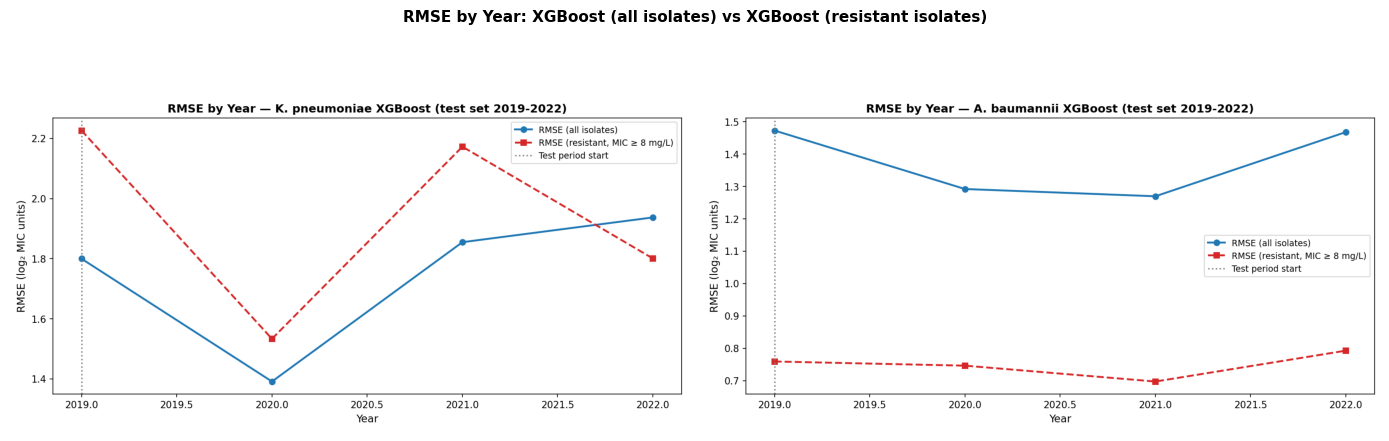

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, sp, label in [
    (axes[0], "kpneumoniae", "K. pneumoniae"),
    (axes[1], "abaumannii",  "A. baumannii"),
]:
    img = MODEL_REPORTS / f"rmse_by_year_{sp}.png"
    if img.exists():
        ax.imshow(mpimg.imread(str(img))); ax.axis("off")
    else:
        ax.text(0.5, 0.5, f"Chart not found.\nRun gen_model_charts.py --species {sp}",
                ha="center", va="center", transform=ax.transAxes)

plt.suptitle("RMSE by Year: XGBoost (all isolates) vs XGBoost (resistant isolates)",
             fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()


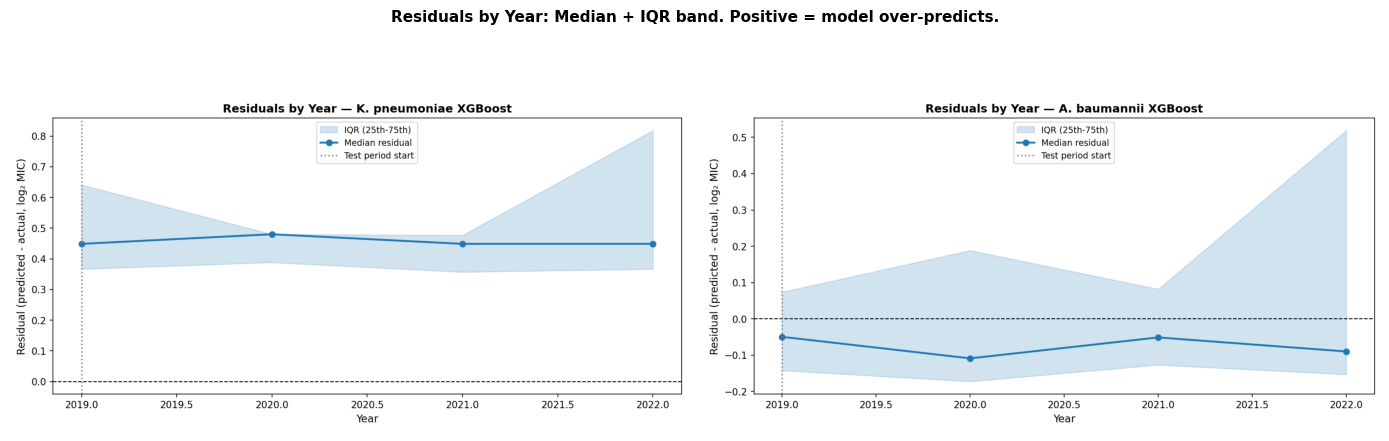

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, sp, label in [
    (axes[0], "kpneumoniae", "K. pneumoniae"),
    (axes[1], "abaumannii",  "A. baumannii"),
]:
    img = MODEL_REPORTS / f"residuals_by_year_{sp}.png"
    if img.exists():
        ax.imshow(mpimg.imread(str(img))); ax.axis("off")
    else:
        ax.text(0.5, 0.5, f"Chart not found.\nRun gen_model_charts.py --species {sp}",
                ha="center", va="center", transform=ax.transAxes)

plt.suptitle("Residuals by Year: Median + IQR band. Positive = model over-predicts.",
             fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()


---
## 7. Model Interpretation (SHAP)

We use **SHAP** (SHapley Additive exPlanations) to explain individual XGBoost predictions.
SHAP assigns each feature a contribution value: how much it shifted the predicted log2(MIC)
up (toward resistance) or down (toward susceptibility).

We report: **Mean |SHAP|** - the average absolute contribution across all test isolates,
representing global feature importance.

> Important: `is_censored` and `pct_censored_year` are **data structure artifacts**, not
> biological predictors. They appear highly ranked because censoring status perfectly
> predicts low MIC (isolates at the panel floor). They are flagged explicitly throughout.


In [15]:
for sp, label in SPECIES.items():
    json_path = API / f"api_{sp}_shap_importance.json"
    if not json_path.exists():
        print(f"SHAP JSON not found for {label}. Run 4_run_export.py --species {sp}")
        continue

    shap_data = json.loads(json_path.read_text())
    df_shap = pd.DataFrame(shap_data[:15])[["rank", "feature", "mean_abs_shap", "note"]]
    df_shap.columns = ["Rank", "Feature", "Mean |SHAP|", "Interpretation"]
    print(f"\nTop 15 SHAP Features - {label}")
    print(df_shap.to_string(index=False))



Top 15 SHAP Features - K. pneumoniae
 Rank           Feature  Mean |SHAP|                                                     Interpretation
    1           KPC_pos      0.94311      KPC carbapenemase — main resistance driver in training period
    2       is_censored      0.54323 DATA ARTIFACT — censored = at panel floor; not a biological signal
    3           OXA_pos      0.50390  OXA-48/OXA-232 carbapenemase — dominant in Europe and Middle East
    4           NDM_pos      0.43841    NDM — fastest-rising mechanism; bypasses avibactam combinations
    5 pct_censored_year      0.33095      Surveillance methodology control — partial out panel artifact
    6        ctry_China      0.30399                                              Country effect: China
    7        ctry_India      0.16020                                              Country effect: India
    8        ctry_Italy      0.11595                                              Country effect: Italy
    9       ctry_Greece   

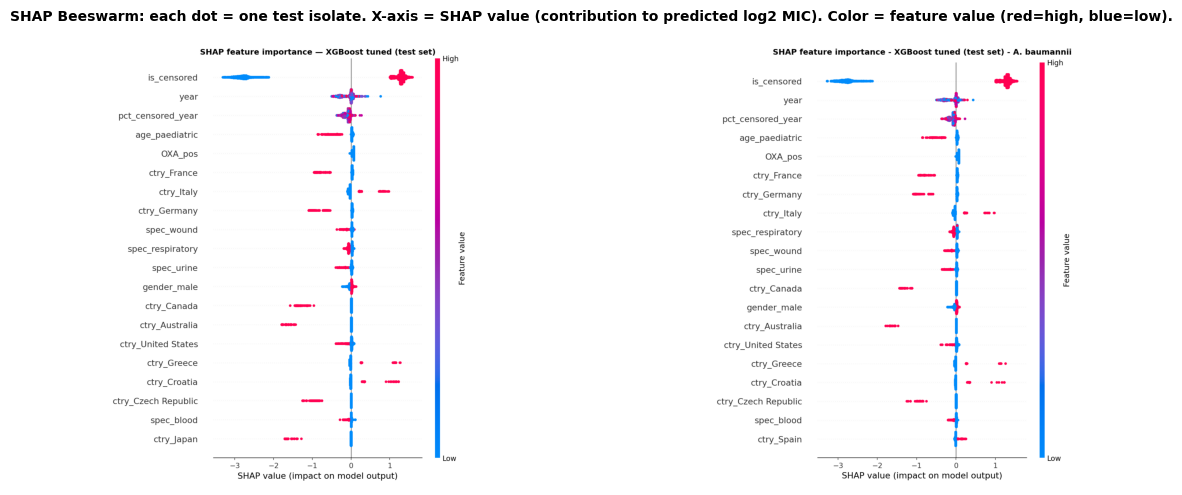

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, sp, label in [
    (axes[0], "kpneumoniae", "K. pneumoniae"),
    (axes[1], "abaumannii",  "A. baumannii"),
]:
    img = MODEL_REPORTS / f"shap_beeswarm_{sp}.png"
    if img.exists():
        ax.imshow(mpimg.imread(str(img))); ax.axis("off")
    else:
        ax.text(0.5, 0.5, f"Chart not found.\nRun gen_model_charts.py --species {sp}",
                ha="center", va="center", transform=ax.transAxes)

plt.suptitle(
    "SHAP Beeswarm: each dot = one test isolate. "
    "X-axis = SHAP value (contribution to predicted log2 MIC). "
    "Color = feature value (red=high, blue=low).",
    fontsize=10, fontweight="bold")
plt.tight_layout(); plt.show()


---
## 8. Discussion

### 8.1 Cross-Species Comparison

| | *K. pneumoniae* | *A. baumannii* |
|---|---|---|
| **Resistance pattern** | Creeping - tripled 2007-2022 (5% -> 20%) | Crisis entrenched - 67-70% throughout 2019-2022 |
| **MIC90 test period** | At or above EUCAST R - panel ceiling (32 mg/L) | At ceiling (32 mg/L) since 2005 |
| **Best RMSE (resistant)** | 1.960 log2 units (XGBoost) | 0.748 log2 units (XGBoost) |
| **Top SHAP feature** | KPC_pos (0.943) - dominant 2004-2018 | is_censored (1.783) - artifact |
| **Year SHAP rank** | #10 - temporal signal dominated by genes | #2 - stronger temporal creep signal |

Lower RMSE for A. baumannii on the resistant subset reflects a simpler prediction task:
resistance is near-universal, so variance is lower. The harder prediction problem is
K. pneumoniae where the model must distinguish susceptible from resistant isolates.

### 8.2 Accuracy / Complexity / Interpretability Tradeoff

| Criterion | Random Forest | XGBoost |
|---|---|---|
| Prediction accuracy (resistant RMSE) | K. pneu: 2.869 · A. bau: 0.983 | K. pneu: **1.960** · A. bau: **0.748** |
| Interpretability | **High** - direct feature importances | Moderate - requires SHAP |
| Complexity | Moderate - parallel trees | High - sequential boosting + Optuna tuning |
| Recommended when | Regulatory review / transparency required | Maximum accuracy on resistant isolates |

**Conclusion:** We recommend XGBoost for prediction tasks and RF for analyses requiring
transparent feature attribution without post-hoc explanation.

### 8.3 Known Limitations

1. **Panel ceiling saturation**: MIC90 hits 32 mg/L for both species in the test period.
   True values may be 64-128+ mg/L. Linear slope underestimates real escalation.

2. **NDM underrepresented in training**: NDM carbapenemase rose to dominance post-2018,
   after the training cutoff. The model is less sensitive to the fastest-growing mechanism.

3. **Bimodal target**: The log2(MIC) distribution violates regression assumptions.
   A tobit regression would handle censored values more rigorously.

4. **Military proxy is broad**: wound + male + 18-60 captures 2,813 isolates of which
   many are non-combat wound infections. Acceptable for PoC scope.

5. **Single dataset**: ATLAS is Pfizer-sponsored; SENTRY (JMI Labs) was excluded for
   consistency. Results should be validated on independent data.


---
## 9. Conclusions

### Main Findings

1. **MIC Creep confirmed in K. pneumoniae**: MIC90 slope = +1.97 mg/L/yr (R2=0.67, p<0.001).
   Resistance tripled from 5% (2007) to 20% (2022). The model detects this trend before
   the EUCAST resistance threshold is consistently breached.

2. **A. baumannii already at crisis level**: MIC90 has been at the 32 mg/L panel ceiling
   since 2005 - 70% of isolates are resistant throughout the test period (2019-2022).
   The temporal creep signal is real (year ranks #2 in SHAP) but superimposed on
   an already-entrenched high baseline.

3. **Best model**: XGBoost (tuned) outperforms Random Forest on the clinically critical
   resistant subset by 32% RMSE (K. pneumoniae) and 24% RMSE (A. baumannii).
   For settings requiring direct interpretability, Random Forest remains the better choice.

### Practical Implications

- The model enables **early-warning surveillance** by identifying MIC trends before
  clinical breakpoints are consistently exceeded.
- A live API + web dashboard is deployed at mic-creep-predict.vercel.app.
- SHAP feature weights must be validated by a domain expert (microbiologist/epidemiologist)
  before use in clinical decision support.

### Future Work

- Retrain with post-2022 data: NDM is rising fast and the model needs updated training
- Tobit regression: principled handling of censored MIC values
- Extend to all WHO priority pathogens and antibiotics beyond meropenem
- Automated retraining pipeline integrated with national AMR surveillance infrastructure


---
## 10. References

1. **EUCAST** (2024). Breakpoint tables for interpretation of MICs and zone diameters, Version 14.0. European Committee on Antimicrobial Susceptibility Testing.

2. **Moradigaravand D. et al.** (2018). Prediction of antibiotic resistance in *Escherichia coli* from large-scale pan-genome data. PLOS Computational Biology, 14(12).

3. **Turnidge J., Paterson D.L.** (2007). Setting and revising antibacterial susceptibility breakpoints. Clinical Microbiology Reviews, 20(3), 391-408.

4. **WHO** (2024). Antimicrobial resistance. Global Priority List of Antibiotic-Resistant Bacteria.

5. **Chen T., Guestrin C.** (2016). XGBoost: A Scalable Tree Boosting System. KDD 2016, 785-794.

6. **Lundberg S.M., Lee S.-I.** (2017). A Unified Approach to Interpreting Model Predictions. NeurIPS, 30.

7. **Vivli AMR Register** (2024). ATLAS dataset (Pfizer). Accessed under Data Use Agreement via vivli.org.

---

*This notebook is reproducible from processed parquets in `data/processed/` and model
artifacts in `models/`. Raw ATLAS data requires a Vivli Data Use Agreement.*
*Code: github.com/AnnGur/mic-creep-predict*
